# Kimi-Audio: Semantic Embedding Distance Analysis

This notebook analyzes the **SEMANTIC** embedding distances between harmful (AdvBench) and benign (VoiceBench) audio samples.

**Key difference from Audio-Flamingo:** Kimi-Audio uses GLM-4 Voice Tokenizer (WhisperVQEncoder) to extract embeddings that capture **speech semantics/meaning**, not just acoustic features.

**Critical insight:** The raw embeddings have ~99.96% of their L2 norm in a common global mean. Centering is REQUIRED to reveal actual semantic variation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Create figures directory
os.makedirs('figures', exist_ok=True)

## 1. Load Embeddings

In [2]:
# Load raw and centered embeddings
cache_dir = Path('embedding_cache_semantic')

voicebench_raw = np.load(cache_dir / 'voicebench_semantic_embeddings.npy')
voicebench_centered = np.load(cache_dir / 'voicebench_semantic_embeddings_centered.npy')
harmful_raw = np.load(cache_dir / 'harmful_semantic_embeddings_en.npy')
harmful_centered = np.load(cache_dir / 'harmful_semantic_embeddings_en_centered.npy')
global_mean = np.load(cache_dir / 'global_mean.npy')

print("Embedding shapes:")
print(f"  VoiceBench (benign): {voicebench_raw.shape}")
print(f"  AdvBench (harmful):  {harmful_raw.shape}")
print(f"  Embedding dimension: {voicebench_raw.shape[1]}")

Embedding shapes:
  VoiceBench (benign): (6083, 1280)
  AdvBench (harmful):  (520, 1280)
  Embedding dimension: 1280


## 2. Centering Analysis: Why It's Critical for Kimi-Audio

In [3]:
# Analyze the effect of centering
print("=" * 70)
print("CENTERING ANALYSIS: Why it's critical for Kimi-Audio")
print("=" * 70)

vb_raw_norm = np.linalg.norm(voicebench_raw, axis=1)
vb_centered_norm = np.linalg.norm(voicebench_centered, axis=1)
global_mean_norm = np.linalg.norm(global_mean)

print(f"\nL2 Norm Statistics:")
print(f"  Global mean L2 norm:           {global_mean_norm:.4f}")
print(f"  VoiceBench raw mean L2 norm:   {vb_raw_norm.mean():.4f}")
print(f"  VoiceBench centered mean L2:   {vb_centered_norm.mean():.4f}")
print(f"\n  Mean dominance ratio: {100 * global_mean_norm / vb_raw_norm.mean():.2f}%")
print(f"  Variance after centering: {100 * vb_centered_norm.mean() / vb_raw_norm.mean():.2f}% of original norm")

print(f"\n=> The global mean captures {100 * global_mean_norm / vb_raw_norm.mean():.1f}% of embedding energy!")
print(f"=> After centering, we reveal the {100 * vb_centered_norm.mean() / vb_raw_norm.mean():.2f}% that contains semantic variation.")

CENTERING ANALYSIS: Why it's critical for Kimi-Audio

L2 Norm Statistics:
  Global mean L2 norm:           34.4347
  VoiceBench raw mean L2 norm:   34.4501
  VoiceBench centered mean L2:   0.3155

  Mean dominance ratio: 99.96%
  Variance after centering: 0.92% of original norm

=> The global mean captures 100.0% of embedding energy!
=> After centering, we reveal the 0.92% that contains semantic variation.


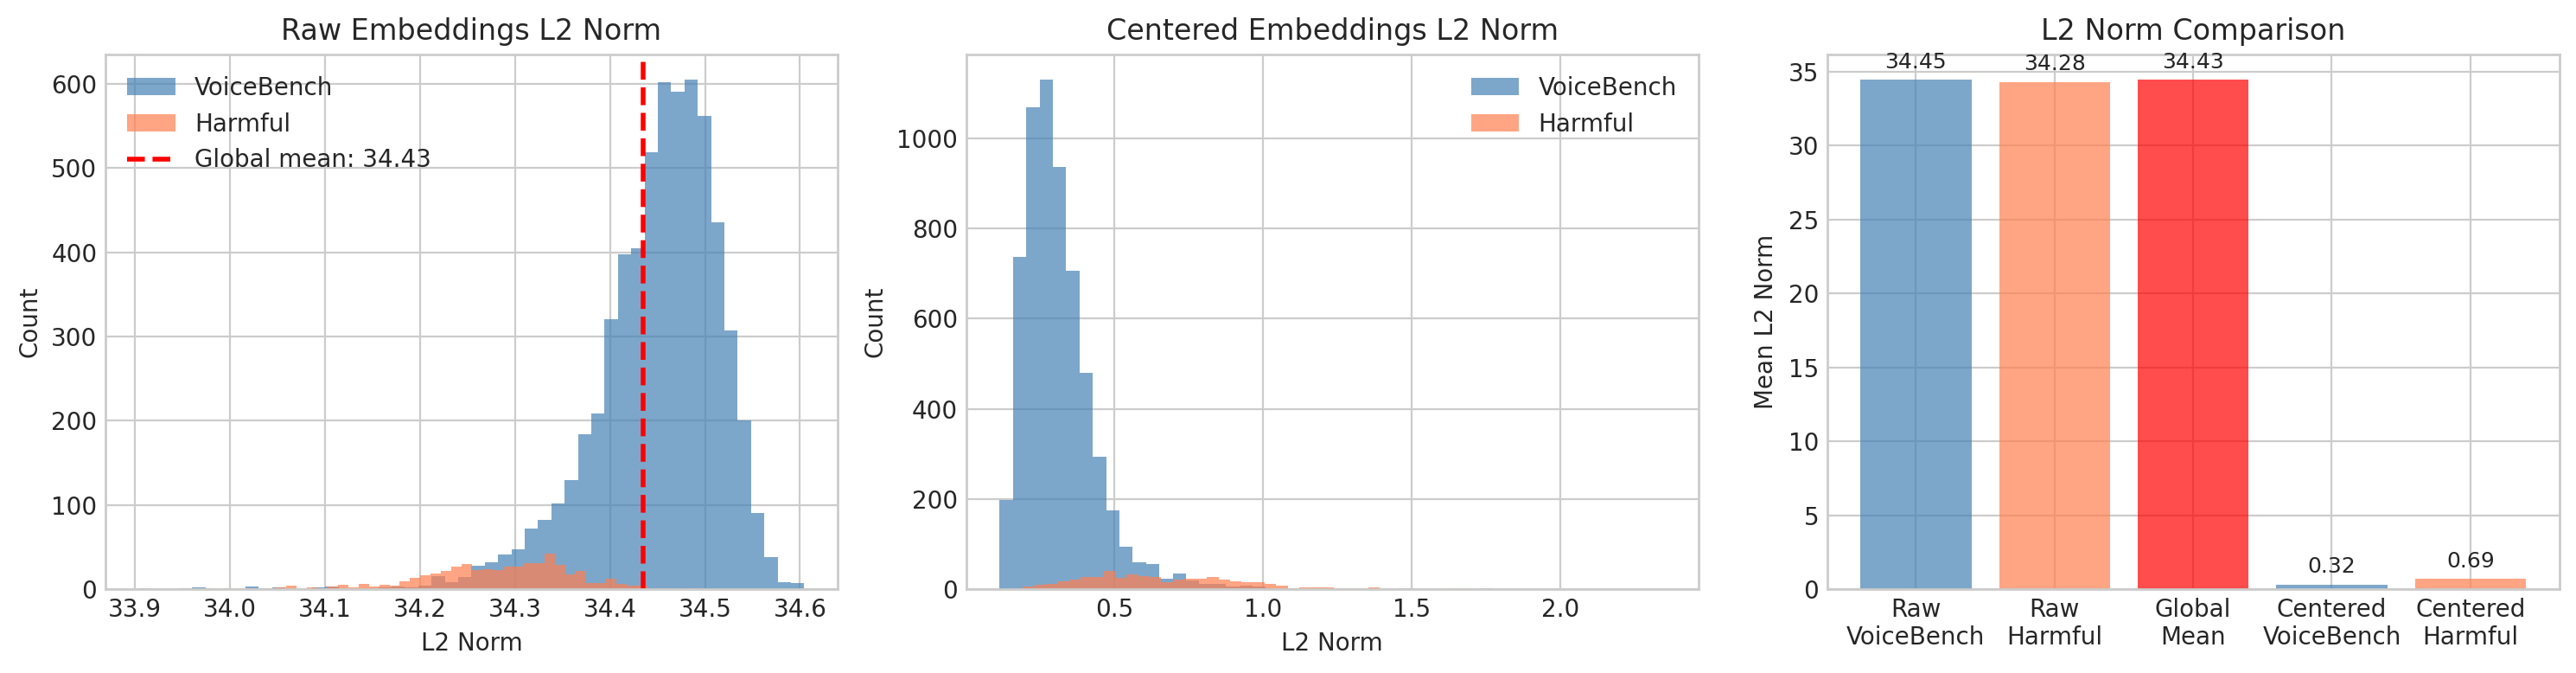

In [4]:
# Visualize the effect of centering on L2 norms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw L2 norms
ax = axes[0]
ax.hist(vb_raw_norm, bins=50, alpha=0.7, label='VoiceBench', color='steelblue')
ax.hist(np.linalg.norm(harmful_raw, axis=1), bins=50, alpha=0.7, label='Harmful', color='coral')
ax.axvline(global_mean_norm, color='red', linestyle='--', linewidth=2, label=f'Global mean: {global_mean_norm:.2f}')
ax.set_xlabel('L2 Norm')
ax.set_ylabel('Count')
ax.set_title('Raw Embeddings L2 Norm')
ax.legend()

# Centered L2 norms
ax = axes[1]
ax.hist(vb_centered_norm, bins=50, alpha=0.7, label='VoiceBench', color='steelblue')
ax.hist(np.linalg.norm(harmful_centered, axis=1), bins=50, alpha=0.7, label='Harmful', color='coral')
ax.set_xlabel('L2 Norm')
ax.set_ylabel('Count')
ax.set_title('Centered Embeddings L2 Norm')
ax.legend()

# Comparison
ax = axes[2]
categories = ['Raw\nVoiceBench', 'Raw\nHarmful', 'Global\nMean', 'Centered\nVoiceBench', 'Centered\nHarmful']
values = [
    vb_raw_norm.mean(),
    np.linalg.norm(harmful_raw, axis=1).mean(),
    global_mean_norm,
    vb_centered_norm.mean(),
    np.linalg.norm(harmful_centered, axis=1).mean()
]
colors = ['steelblue', 'coral', 'red', 'steelblue', 'coral']
bars = ax.bar(categories, values, color=colors, alpha=0.7)
ax.set_ylabel('Mean L2 Norm')
ax.set_title('L2 Norm Comparison')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/centering_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Compute Distance/Similarity Metrics

In [5]:
def compute_cosine_similarity(emb1, emb2):
    """Compute pairwise cosine similarity"""
    emb1_norm = emb1 / (np.linalg.norm(emb1, axis=1, keepdims=True) + 1e-8)
    emb2_norm = emb2 / (np.linalg.norm(emb2, axis=1, keepdims=True) + 1e-8)
    return np.dot(emb1_norm, emb2_norm.T)

def compute_cosine_distance(emb1, emb2):
    """Compute pairwise cosine distance (1 - similarity)"""
    return 1 - compute_cosine_similarity(emb1, emb2)

In [6]:
# Compute distances using CENTERED embeddings (this is what the filtering uses)
print("Computing distances using CENTERED embeddings...")
all_distances = compute_cosine_distance(voicebench_centered, harmful_centered)
min_distances = all_distances.min(axis=1)

# Also compute for raw embeddings to show the difference
print("Computing distances using RAW embeddings (for comparison)...")
raw_distances = compute_cosine_distance(voicebench_raw, harmful_raw)
min_distances_raw = raw_distances.min(axis=1)

print(f"\nDistance matrix shape: {all_distances.shape}")
print(f"Min distances shape: {min_distances.shape}")

Computing distances using CENTERED embeddings...
Computing distances using RAW embeddings (for comparison)...

Distance matrix shape: (6083, 520)
Min distances shape: (6083,)


In [7]:
# Compare raw vs centered distances
print("=" * 70)
print("RAW vs CENTERED Distance Comparison")
print("=" * 70)

print(f"\nRAW Embeddings (all samples look similar!):")
print(f"  Mean distance:   {min_distances_raw.mean():.6f}")
print(f"  Std distance:    {min_distances_raw.std():.6f}")
print(f"  Range: [{min_distances_raw.min():.6f}, {min_distances_raw.max():.6f}]")

print(f"\nCENTERED Embeddings (reveals semantic variation):")
print(f"  Mean distance:   {min_distances.mean():.6f}")
print(f"  Std distance:    {min_distances.std():.6f}")
print(f"  Range: [{min_distances.min():.6f}, {min_distances.max():.6f}]")

print(f"\n=> Raw distances are TINY ({min_distances_raw.mean():.4f}) because all embeddings are dominated by global mean")
print(f"=> Centered distances spread out ({min_distances.mean():.4f}), revealing actual semantic differences")

RAW vs CENTERED Distance Comparison

RAW Embeddings (all samples look similar!):
  Mean distance:   0.000031
  Std distance:    0.000015
  Range: [0.000008, 0.000405]

CENTERED Embeddings (reveals semantic variation):
  Mean distance:   0.393631
  Std distance:    0.201189
  Range: [0.009169, 1.132833]

=> Raw distances are TINY (0.0000) because all embeddings are dominated by global mean
=> Centered distances spread out (0.3936), revealing actual semantic differences


## 4. Distance Distribution Analysis (Centered Embeddings)

In [8]:
print("=" * 70)
print("CENTERED EMBEDDING Distance Statistics")
print("=" * 70)

print(f"\nDistance to Nearest Harmful Sample:")
print(f"  Mean:   {min_distances.mean():.6f}")
print(f"  Std:    {min_distances.std():.6f}")
print(f"  Min:    {min_distances.min():.6f}")
print(f"  Max:    {min_distances.max():.6f}")
print(f"  Median: {np.median(min_distances):.6f}")

print(f"\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    val = np.percentile(min_distances, p)
    print(f"  {p:3d}th percentile: {val:.6f}")

CENTERED EMBEDDING Distance Statistics

Distance to Nearest Harmful Sample:
  Mean:   0.393631
  Std:    0.201189
  Min:    0.009169
  Max:    1.132833
  Median: 0.361425

Percentiles:
    1th percentile: 0.040266
    5th percentile: 0.095076
   10th percentile: 0.152212
   25th percentile: 0.250214
   50th percentile: 0.361425
   75th percentile: 0.522531
   90th percentile: 0.679536
   95th percentile: 0.769635
   99th percentile: 0.917288


/tmp/ipykernel_647753/1136389397.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(threshold_data, labels=threshold_labels, patch_artist=True)


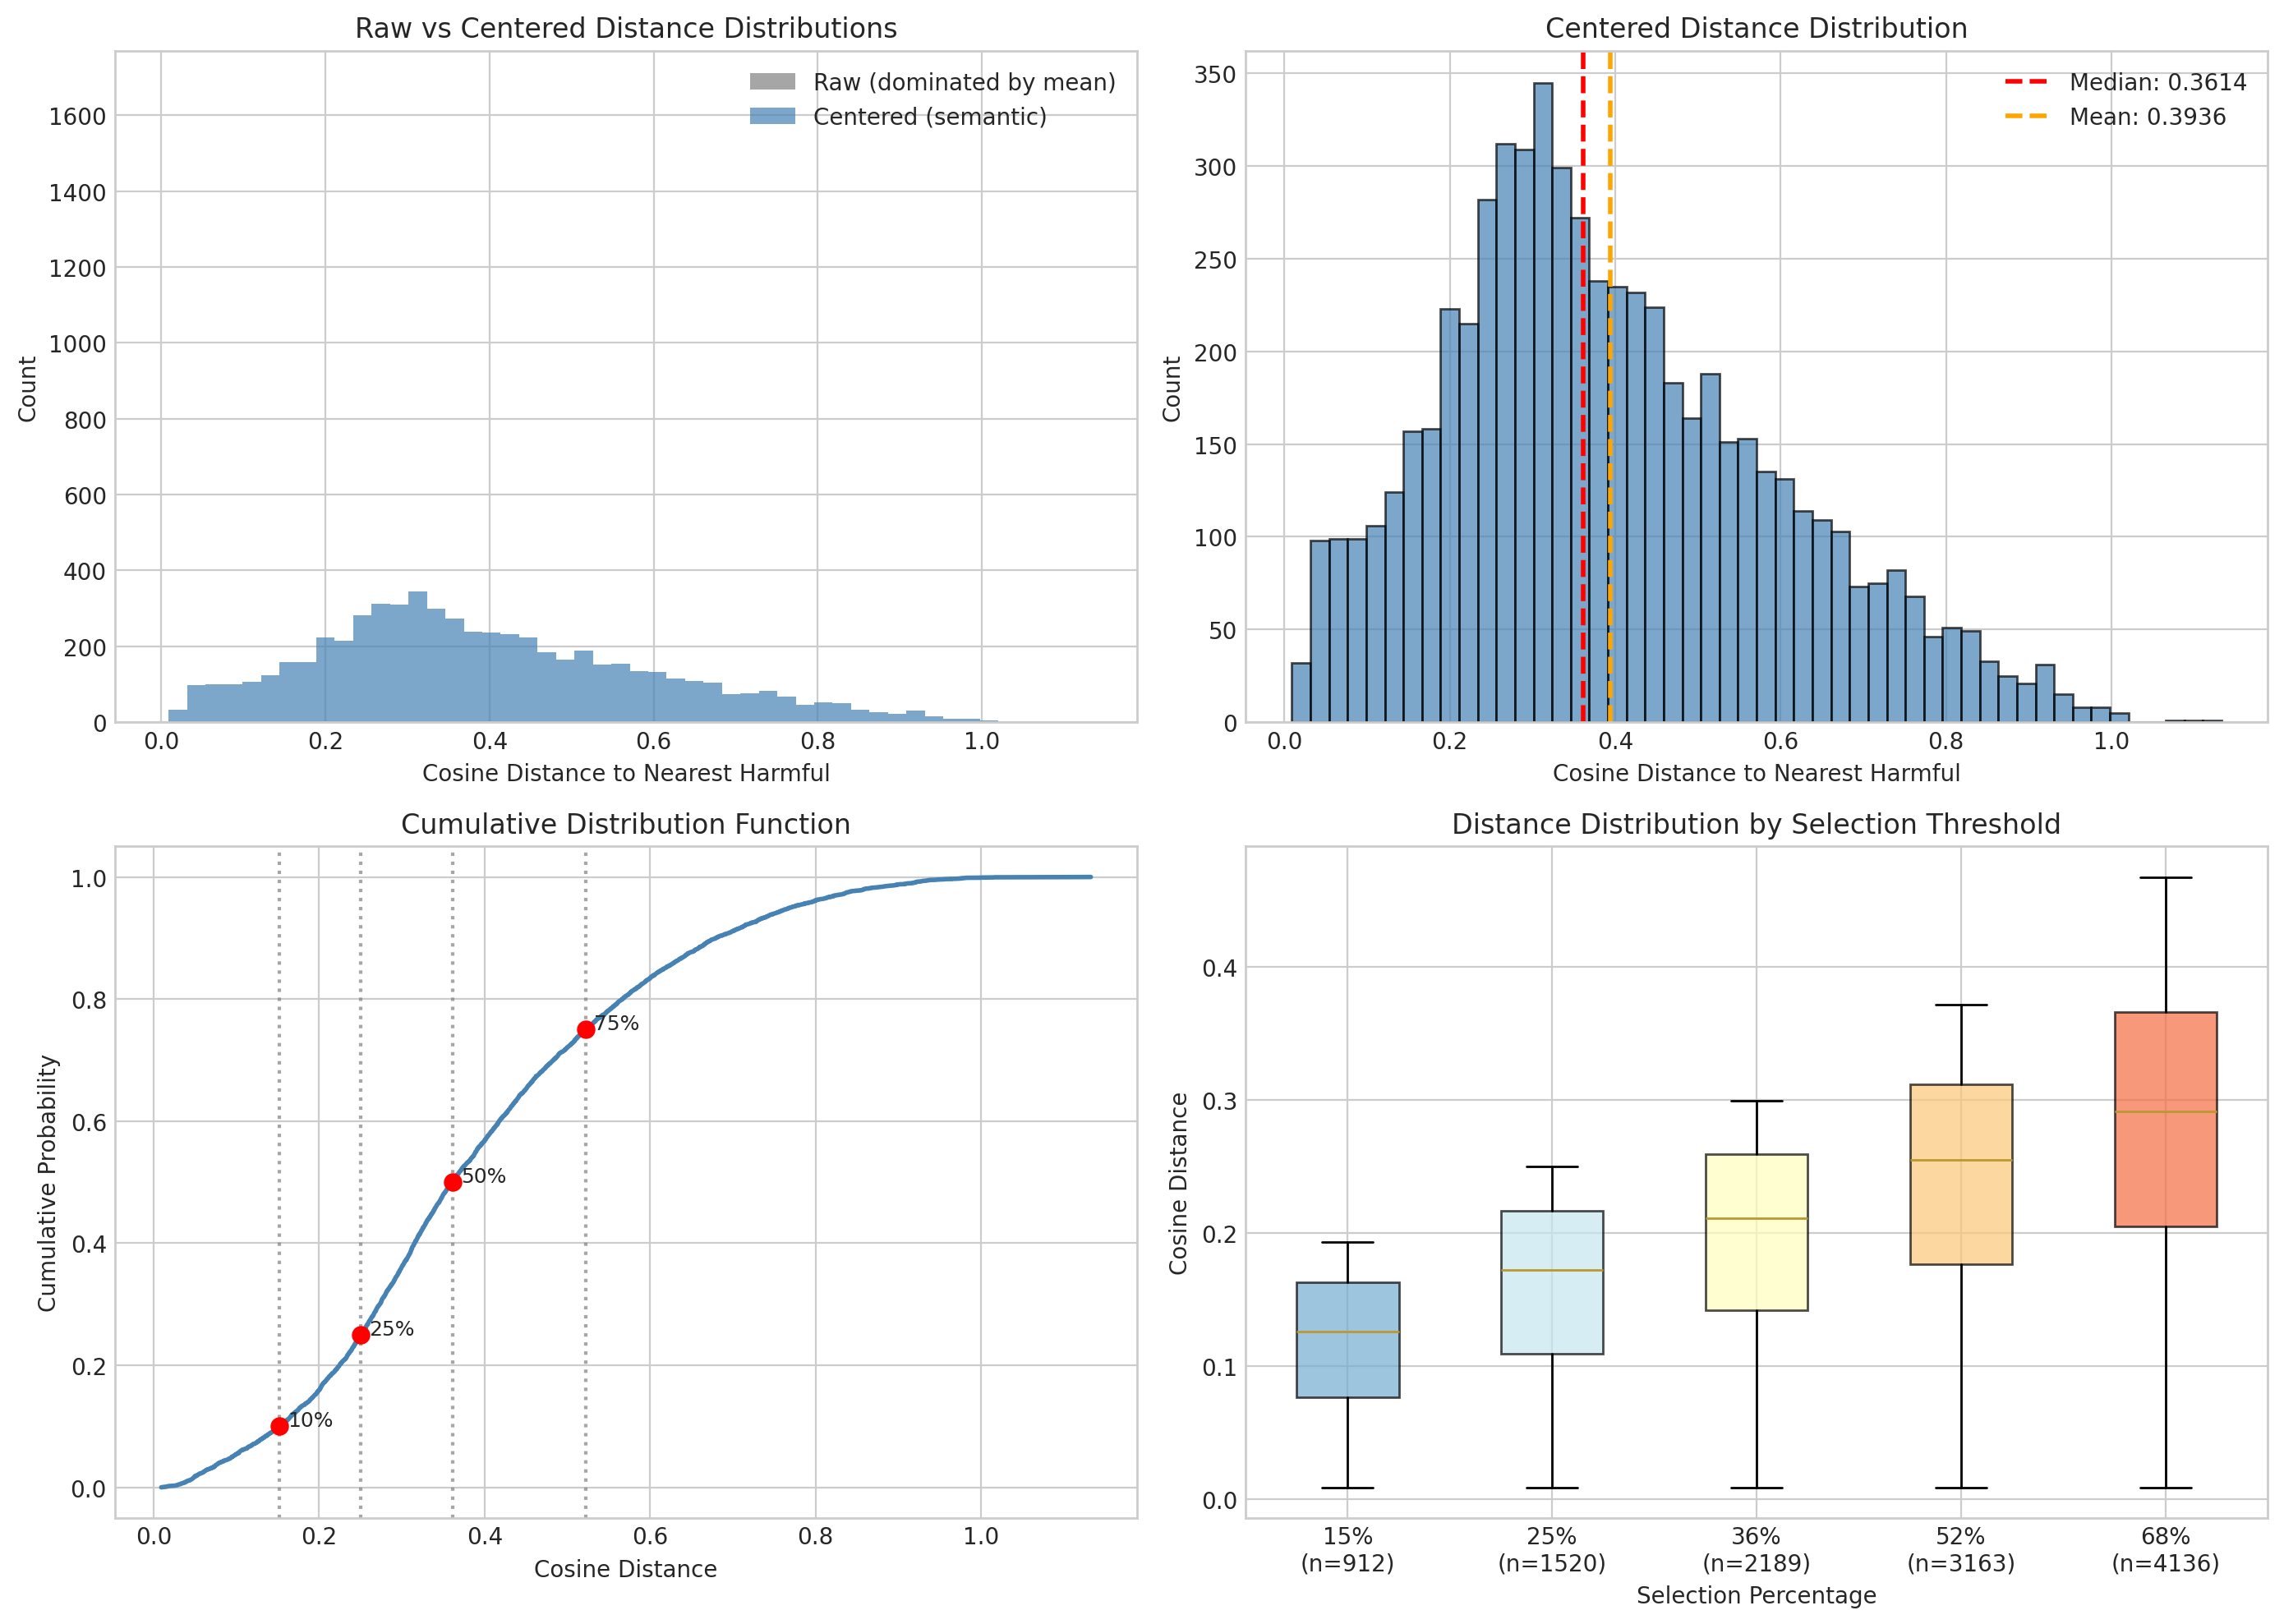

In [9]:
# Visualize distance distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Compare raw vs centered distributions
ax = axes[0, 0]
ax.hist(min_distances_raw, bins=50, alpha=0.7, label='Raw (dominated by mean)', color='gray')
ax.hist(min_distances, bins=50, alpha=0.7, label='Centered (semantic)', color='steelblue')
ax.set_xlabel('Cosine Distance to Nearest Harmful')
ax.set_ylabel('Count')
ax.set_title('Raw vs Centered Distance Distributions')
ax.legend()

# 2. Centered distance histogram with statistics
ax = axes[0, 1]
ax.hist(min_distances, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.median(min_distances), color='red', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(min_distances):.4f}')
ax.axvline(min_distances.mean(), color='orange', linestyle='--', linewidth=2, 
           label=f'Mean: {min_distances.mean():.4f}')
ax.set_xlabel('Cosine Distance to Nearest Harmful')
ax.set_ylabel('Count')
ax.set_title('Centered Distance Distribution')
ax.legend()

# 3. Cumulative distribution
ax = axes[1, 0]
sorted_distances = np.sort(min_distances)
cdf = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
ax.plot(sorted_distances, cdf, linewidth=2, color='steelblue')
for p in [10, 25, 50, 75]:
    val = np.percentile(min_distances, p)
    ax.axvline(val, color='gray', linestyle=':', alpha=0.7)
    ax.scatter([val], [p/100], color='red', s=50, zorder=5)
    ax.annotate(f'{p}%', (val + 0.01, p/100), fontsize=9)
ax.set_xlabel('Cosine Distance')
ax.set_ylabel('Cumulative Probability')
ax.set_title('Cumulative Distribution Function')

# 4. Box plot of distances at different thresholds
ax = axes[1, 1]
thresholds = [0.15, 0.25, 0.36, 0.52, 0.68]  # From the data files
threshold_data = []
threshold_labels = []
sorted_indices = np.argsort(min_distances)
for t in thresholds:
    n_select = int(len(min_distances) * t)
    selected_idx = sorted_indices[:n_select]
    threshold_data.append(min_distances[selected_idx])
    threshold_labels.append(f'{int(t*100)}%\n(n={n_select})')

bp = ax.boxplot(threshold_data, labels=threshold_labels, patch_artist=True)
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(thresholds)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Selection Percentage')
ax.set_ylabel('Cosine Distance')
ax.set_title('Distance Distribution by Selection Threshold')

plt.tight_layout()
plt.savefig('figures/distance_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. t-SNE Visualization

In [10]:
from sklearn.manifold import TSNE

# Combine centered embeddings for visualization
all_embeddings = np.vstack([voicebench_centered, harmful_centered])
n_vb = len(voicebench_centered)
n_ab = len(harmful_centered)

print(f"Combined embeddings shape: {all_embeddings.shape}")

# Create labels based on distance percentiles
# 0 = far from harmful (top 50% distance), 1 = close to harmful (bottom 50%), 2 = harmful
median_dist = np.median(min_distances)
labels = np.zeros(len(all_embeddings), dtype=int)
labels[min_distances <= median_dist] = 1  # Close to harmful
labels[n_vb:] = 2  # Harmful samples

Combined embeddings shape: (6603, 1280)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 6603 but size of corresponding boolean axis is 6083

In [ ]:
# Run t-SNE on centered embeddings
print("Running t-SNE on centered embeddings...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
embeddings_2d = tsne.fit_transform(all_embeddings)
print("t-SNE completed!")

In [ ]:
# Plot t-SNE results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Categories
ax = axes[0]
colors = ['#a8dadc', '#e63946', '#1d3557']  # light blue, red, dark blue
labels_names = ['Benign (Far from Harmful)', 'Benign (Close to Harmful)', 'Harmful (AdvBench)']
markers = ['o', 'o', '^']
sizes = [20, 40, 100]
alphas = [0.3, 0.7, 0.9]

for i, (label_name, color, marker, size, alpha) in enumerate(zip(labels_names, colors, markers, sizes, alphas)):
    mask = labels == i
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
               c=color, label=label_name, s=size, alpha=alpha, marker=marker, edgecolors='white', linewidth=0.5)

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('t-SNE: Semantic Embeddings (Centered)')
ax.legend(loc='best', fontsize=10)

# Plot 2: Color by distance
ax = axes[1]
vb_embeddings_2d = embeddings_2d[:n_vb]
ab_embeddings_2d = embeddings_2d[n_vb:]

scatter = ax.scatter(vb_embeddings_2d[:, 0], vb_embeddings_2d[:, 1], 
                     c=min_distances, cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors='white', linewidth=0.3)
ax.scatter(ab_embeddings_2d[:, 0], ab_embeddings_2d[:, 1], 
           c='black', marker='^', s=100, label='Harmful (AdvBench)', alpha=0.9, edgecolors='white', linewidth=1)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cosine Distance to Nearest Harmful')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('t-SNE: Colored by Distance to Harmful')
ax.legend(loc='best')

plt.tight_layout()
plt.savefig('figures/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. UMAP Visualization (if available)

In [ ]:
try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("UMAP not installed. Install with: pip install umap-learn")
    HAS_UMAP = False

In [ ]:
if HAS_UMAP:
    print("Running UMAP on centered embeddings...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, verbose=True)
    embeddings_umap = reducer.fit_transform(all_embeddings)
    print("UMAP completed!")

In [ ]:
if HAS_UMAP:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax = axes[0]
    for i, (label_name, color, marker, size, alpha) in enumerate(zip(labels_names, colors, markers, sizes, alphas)):
        mask = labels == i
        ax.scatter(embeddings_umap[mask, 0], embeddings_umap[mask, 1], 
                   c=color, label=label_name, s=size, alpha=alpha, marker=marker, edgecolors='white', linewidth=0.5)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title('UMAP: Semantic Embeddings (Centered)')
    ax.legend(loc='best', fontsize=10)

    ax = axes[1]
    vb_umap = embeddings_umap[:n_vb]
    ab_umap = embeddings_umap[n_vb:]
    scatter = ax.scatter(vb_umap[:, 0], vb_umap[:, 1], 
                         c=min_distances, cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors='white', linewidth=0.3)
    ax.scatter(ab_umap[:, 0], ab_umap[:, 1], 
               c='black', marker='^', s=100, label='Harmful (AdvBench)', alpha=0.9, edgecolors='white', linewidth=1)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Cosine Distance to Nearest Harmful')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title('UMAP: Colored by Distance to Harmful')
    ax.legend(loc='best')

    plt.tight_layout()
    plt.savefig('figures/umap_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Nearest Neighbor Analysis

In [ ]:
# Which harmful samples are most often the nearest neighbor?
nearest_harmful_idx = np.argmin(all_distances, axis=1)
unique, counts = np.unique(nearest_harmful_idx, return_counts=True)
nn_counts = dict(zip(unique, counts))
sorted_harmful = sorted(nn_counts.items(), key=lambda x: x[1], reverse=True)

print("=" * 70)
print("NEAREST NEIGHBOR ANALYSIS")
print("=" * 70)
print(f"\nHarmful samples with at least 1 match: {len(unique)} / {len(harmful_centered)}")
print(f"\nTop 15 most frequently matched harmful samples:")
for idx, count in sorted_harmful[:15]:
    pct = count / len(min_distances) * 100
    print(f"  Harmful #{idx:3d}: {count:4d} benign matches ({pct:.1f}%)")

top_5_matches = sum([c for _, c in sorted_harmful[:5]])
print(f"\nTop 5 harmful samples cover: {top_5_matches/len(min_distances)*100:.1f}% of benign samples")

In [ ]:
# Plot nearest neighbor distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_counts = [nn_counts.get(i, 0) for i in range(len(harmful_centered))]

ax = axes[0]
ax.bar(range(len(all_counts)), sorted(all_counts, reverse=True), color='steelblue', alpha=0.7)
ax.set_xlabel('Harmful Sample (sorted by count)')
ax.set_ylabel('Number of Benign Matches')
ax.set_title('Benign Samples per Harmful Sample')

ax = axes[1]
ax.hist(all_counts, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Number of Benign Matches')
ax.set_ylabel('Number of Harmful Samples')
ax.set_title('Distribution of Match Counts')
ax.axvline(np.mean(all_counts), color='red', linestyle='--', label=f'Mean: {np.mean(all_counts):.1f}')
ax.legend()

plt.tight_layout()
plt.savefig('figures/nearest_neighbor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. PCA Analysis

In [ ]:
from sklearn.decomposition import PCA

# Run PCA on centered embeddings
pca = PCA(n_components=50)
pca.fit(all_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, 51), pca.explained_variance_ratio_ * 100, color='steelblue', alpha=0.7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Explained Variance by PC (Centered Embeddings)')

ax = axes[1]
cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(range(1, 51), cumulative_var, 'o-', color='steelblue')
ax.axhline(90, color='red', linestyle='--', label='90% variance')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Variance (%)')
ax.set_title('Cumulative Explained Variance')
ax.legend()

plt.tight_layout()
plt.savefig('figures/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Components for 90% variance: {np.argmax(cumulative_var >= 90) + 1}")
print(f"Components for 95% variance: {np.argmax(cumulative_var >= 95) + 1}")

In [ ]:
# 2D PCA visualization
pca_2d = PCA(n_components=2)
embeddings_pca = pca_2d.fit_transform(all_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for i, (label_name, color, marker, size, alpha) in enumerate(zip(labels_names, colors, markers, sizes, alphas)):
    mask = labels == i
    ax.scatter(embeddings_pca[mask, 0], embeddings_pca[mask, 1], 
               c=color, label=label_name, s=size, alpha=alpha, marker=marker, edgecolors='white', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA: Semantic Embeddings (Centered)')
ax.legend(loc='best')

ax = axes[1]
vb_pca = embeddings_pca[:n_vb]
ab_pca = embeddings_pca[n_vb:]
scatter = ax.scatter(vb_pca[:, 0], vb_pca[:, 1], 
                     c=min_distances, cmap='RdYlBu_r', s=30, alpha=0.6, edgecolors='white', linewidth=0.3)
ax.scatter(ab_pca[:, 0], ab_pca[:, 1], 
           c='black', marker='^', s=100, label='Harmful', alpha=0.9, edgecolors='white', linewidth=1)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cosine Distance')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA: Colored by Distance')
ax.legend(loc='best')

plt.tight_layout()
plt.savefig('figures/pca_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Distance Heatmap

In [ ]:
# Sample for heatmap visualization
n_sample_benign = 50
n_sample_harmful = min(50, len(harmful_centered))

sorted_indices = np.argsort(min_distances)
sample_benign_indices = np.concatenate([
    sorted_indices[:n_sample_benign//2],  # Closest
    sorted_indices[-n_sample_benign//2:]  # Farthest
])
sample_harmful_indices = np.linspace(0, len(harmful_centered)-1, n_sample_harmful, dtype=int)

distance_subset = all_distances[sample_benign_indices][:, sample_harmful_indices]

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(distance_subset, aspect='auto', cmap='RdYlBu')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Distance', fontsize=12)
ax.set_xlabel('Harmful Sample Index', fontsize=12)
ax.set_ylabel('Benign Sample (Top: Closest, Bottom: Farthest)', fontsize=12)
ax.set_title('Distance Heatmap (Centered Embeddings)', fontsize=14)
ax.axhline(n_sample_benign//2 - 0.5, color='white', linewidth=2, linestyle='--')

plt.tight_layout()
plt.savefig('figures/distance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Threshold Analysis (Matching Dataset Files)

In [ ]:
# Analyze the thresholds used in the actual data files
data_thresholds = [0.15, 0.25, 0.36, 0.52, 0.68]  # From voicebench_filtered_advbench_*.jsonl

print("=" * 70)
print("THRESHOLD ANALYSIS (Matching Dataset Files)")
print("=" * 70)

sorted_indices = np.argsort(min_distances)

for t in data_thresholds:
    n_select = int(len(min_distances) * t)
    selected_idx = sorted_indices[:n_select]
    selected_dists = min_distances[selected_idx]
    
    print(f"\n{int(t*100)}% Selection (n={n_select}):")
    print(f"  Distance range: [{selected_dists.min():.4f}, {selected_dists.max():.4f}]")
    print(f"  Mean distance:  {selected_dists.mean():.4f}")
    print(f"  Threshold (max distance): {selected_dists.max():.4f}")

In [ ]:
# Violin plot for dataset thresholds
import pandas as pd

selection_data = []
for t in data_thresholds:
    n_select = int(len(min_distances) * t)
    selected_idx = sorted_indices[:n_select]
    for d in min_distances[selected_idx]:
        selection_data.append({'Threshold': f'{int(t*100)}%', 'Distance': d})

selection_df = pd.DataFrame(selection_data)

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=selection_df, x='Threshold', y='Distance', ax=ax, palette='RdYlBu_r')
ax.set_xlabel('Selection Percentage', fontsize=12)
ax.set_ylabel('Cosine Distance to Nearest Harmful', fontsize=12)
ax.set_title('Distance Distribution by Selection Threshold', fontsize=14)

plt.tight_layout()
plt.savefig('figures/violin_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary Statistics

In [ ]:
# Create summary table
summary_data = {
    'Metric': [
        'Total VoiceBench (Benign) Samples',
        'Total AdvBench (Harmful) Samples',
        'Embedding Dimension',
        'Embedding Type',
        '',
        'Global Mean L2 Norm',
        'Raw Embedding Mean L2 Norm',
        'Centered Embedding Mean L2 Norm',
        'Mean Dominance Ratio',
        '',
        'Mean Distance (Centered)',
        'Std Distance (Centered)',
        'Min Distance',
        'Max Distance',
        'Median Distance',
        '',
        'Harmful Samples with Matches',
        'Top 5 Cover % of Benign',
    ],
    'Value': [
        len(voicebench_centered),
        len(harmful_centered),
        voicebench_centered.shape[1],
        'Semantic (GLM-4 Voice Tokenizer)',
        '',
        f'{global_mean_norm:.4f}',
        f'{vb_raw_norm.mean():.4f}',
        f'{vb_centered_norm.mean():.4f}',
        f'{100 * global_mean_norm / vb_raw_norm.mean():.1f}%',
        '',
        f'{min_distances.mean():.6f}',
        f'{min_distances.std():.6f}',
        f'{min_distances.min():.6f}',
        f'{min_distances.max():.6f}',
        f'{np.median(min_distances):.6f}',
        '',
        f'{len(unique)} / {len(harmful_centered)}',
        f'{top_5_matches/len(min_distances)*100:.1f}%',
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

summary_df.to_csv('figures/kimi_embedding_analysis_summary.csv', index=False)
print("\nSummary saved to figures/kimi_embedding_analysis_summary.csv")

## 12. Comparison with Audio-Flamingo (if both results available)

In [ ]:
print("=" * 70)
print("KEY DIFFERENCES: Kimi-Audio vs Audio-Flamingo Embeddings")
print("=" * 70)

print("""
Kimi-Audio (This Analysis):
  - Uses SEMANTIC embeddings (GLM-4 Voice Tokenizer / WhisperVQEncoder)
  - Captures speech MEANING, not just acoustic features
  - Requires CENTERING: 99.96% of L2 norm is in global mean
  - Distance range (centered): [{:.4f}, {:.4f}]
  - Mean distance: {:.4f}

Audio-Flamingo (Previous Analysis):
  - Uses ACOUSTIC embeddings (Whisper encoder + projector)
  - Captures audio characteristics (voice, tone, quality)
  - No centering needed
  - Distance range: [0.0136, 0.1378]
  - Mean distance: 0.0332

Implication:
  - Kimi-Audio filtering is based on SEMANTIC similarity
  - Audio-Flamingo filtering is based on ACOUSTIC similarity
  - Both select benign samples that are "close" to harmful samples,
    but in different embedding spaces!
""".format(min_distances.min(), min_distances.max(), min_distances.mean()))

## 13. Generated Figures List

In [ ]:
print("\n" + "="*60)
print("Generated Figures:")
print("="*60)
figures = [
    'figures/centering_analysis.png',
    'figures/distance_distributions.png',
    'figures/tsne_embeddings.png',
    'figures/umap_embeddings.png (if UMAP installed)',
    'figures/nearest_neighbor_analysis.png',
    'figures/pca_variance.png',
    'figures/pca_embeddings.png',
    'figures/distance_heatmap.png',
    'figures/violin_thresholds.png',
    'figures/kimi_embedding_analysis_summary.csv'
]
for fig in figures:
    print(f"  - {fig}")